## 0. Loading

In [13]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt

# Create directories if they don't exist
os.makedirs('./data', exist_ok=True)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Setup complete.")

# Load all CSV files
print("Loading data files...")

df = pd.read_csv('./data/CDC Diabetes Dataset.csv')
print(f"Raw CDC Diabetes Dataset: {df.shape}")

print("\nData loading complete.")

Setup complete.
Loading data files...
Raw CDC Diabetes Dataset: (253680, 22)

Data loading complete.


## 1. Data Preparation

In [14]:
# Keep only non-diabetic (0) and diabetic (2)
df_clf = df[df['Diabetes_012'].isin([0, 2])].copy()

# Binary label: 0 = no diabetes, 1 = diabetes
df_clf['diabetes_binary'] = (df_clf['Diabetes_012'] == 2).astype(int)


# Features to use for classification
clf_features = [
    'HighBP',
    'HighChol',
    'CholCheck',
    'BMI',
    'Smoker',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'AnyHealthcare',
    'NoDocbcCost',
    'GenHlth',
    'MentHlth',
    'PhysHlth',
    'DiffWalk',
    'Sex',
    'Age',
    'Education',
    'Income'
]


## 2. Correlation Matrix

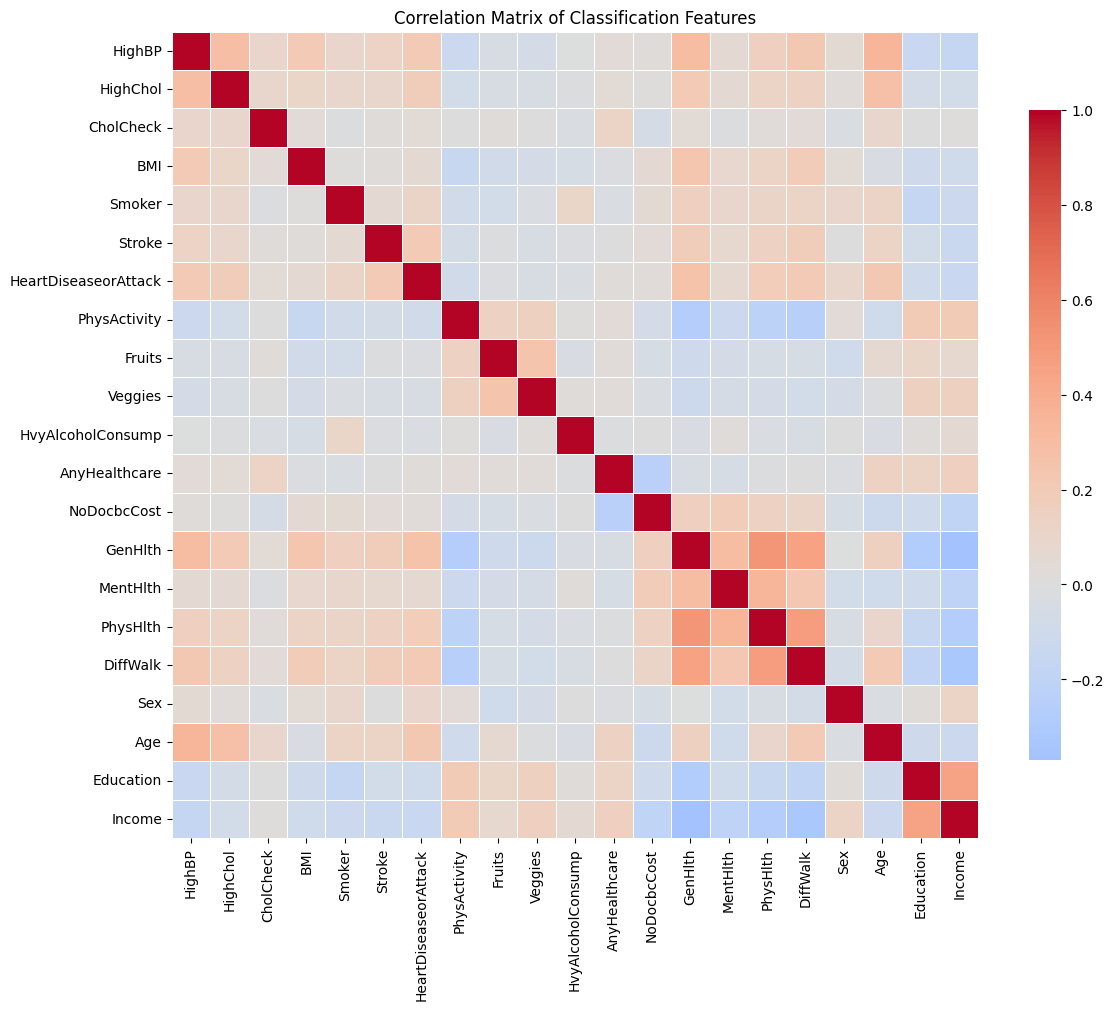

In [15]:
X_corr = df_clf[clf_features]
corr_matrix = X_corr.corr(method='pearson')
corr_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix of Classification Features')
plt.tight_layout()
plt.show()

## 3. Train-test split

In [16]:
## Train-test split for classification
from sklearn.model_selection import train_test_split

X = df_clf[clf_features]
y = df_clf['diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [17]:
## Check class distribution
y_train.value_counts(normalize=True)


diabetes_binary
0    0.858075
1    0.141925
Name: proportion, dtype: float64

## 4. Scaling

In [18]:
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

num_features = [
    'BMI', 'PhysHlth', 'MentHlth',
    'Age', 'GenHlth', 'Income', 'Education'
]

bin_features = [f for f in clf_features if f not in num_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('bin', 'passthrough', bin_features)
    ]
)

## 5. Baseline

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_score,
                             precision_recall_curve)

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1),
    "GaussianNB": GaussianNB(),
    "RandomForest": RandomForestClassifier(
        random_state=42, class_weight="balanced", n_estimators=300, n_jobs=-1
    ),
}

def eval_model(name, model):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", model)
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    print(f"\n===== {name} =====")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=4))

    if y_proba is not None:
        print("ROC-AUC:", roc_auc_score(y_test, y_proba))
        print("Precision:", precision_score(y_test, y_pred))

    return pipe

pipes = {}
for name, m in models.items():
    pipes[name] = eval_model(name, m)


c:\Users\kevin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



===== LogReg =====
Confusion matrix:
 [[31303 11438]
 [ 1618  5451]]
              precision    recall  f1-score   support

           0     0.9509    0.7324    0.8274     42741
           1     0.3228    0.7711    0.4550      7069

    accuracy                         0.7379     49810
   macro avg     0.6368    0.7518    0.6412     49810
weighted avg     0.8617    0.7379    0.7746     49810

ROC-AUC: 0.8288010269701973
Precision: 0.32275445556279236

===== GaussianNB =====
Confusion matrix:
 [[34558  8183]
 [ 3045  4024]]
              precision    recall  f1-score   support

           0     0.9190    0.8085    0.8603     42741
           1     0.3296    0.5692    0.4175      7069

    accuracy                         0.7746     49810
   macro avg     0.6243    0.6889    0.6389     49810
weighted avg     0.8354    0.7746    0.7974     49810

ROC-AUC: 0.7865103216437912
Precision: 0.32964692389612515

===== RandomForest =====
Confusion matrix:
 [[41447  1294]
 [ 5808  1261]]
        

## 6. CV for RF

In [20]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import randint

rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1))
])

param_dist = {
    "clf__n_estimators": [120, 180, 240, 300],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_leaf": [1, 2, 4, 8],
    "clf__min_samples_split": [2, 5, 10],
    "clf__max_features": ["sqrt", 0.5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=25,
    scoring="precision",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

best_rf = search.best_estimator_
y_proba = best_rf.predict_proba(X_test)[:, 1]
y_pred = best_rf.predict(X_test)
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test Precision:", precision_score(y_test, y_pred))


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_features': 0.5, 'clf__max_depth': 30}
Best CV score: 0.4441779883555384
Test ROC-AUC: 0.8132078653195429
Test Precision: 0.44390407512996816


In [21]:
final_model = best_rf
from sklearn.metrics import classification_report, confusion_matrix

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

Confusion matrix:
 [[39425  3316]
 [ 4422  2647]]
              precision    recall  f1-score   support

           0     0.8991    0.9224    0.9106     42741
           1     0.4439    0.3745    0.4062      7069

    accuracy                         0.8446     49810
   macro avg     0.6715    0.6484    0.6584     49810
weighted avg     0.8345    0.8446    0.8390     49810



In [22]:
import numpy as np
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report

prec, rec, thr = precision_recall_curve(y_test, y_proba)

# 例：优先控制 FP → 设定目标 precision
target_precision = 0.80
mask = prec[:-1] >= target_precision

if mask.any():
    idx = np.argmax(rec[:-1][mask])          # 在满足precision前提下最大recall
    chosen_thr = thr[mask][idx]
else:
    chosen_thr = 0.5

y_pred_thr = (y_proba >= chosen_thr).astype(int)
print("Chosen threshold:", chosen_thr)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_thr))
print(classification_report(y_test, y_pred_thr, digits=4))


Chosen threshold: 0.8736331275267578
Confusion matrix:
 [[42725    16]
 [ 7003    66]]
              precision    recall  f1-score   support

           0     0.8592    0.9996    0.9241     42741
           1     0.8049    0.0093    0.0185      7069

    accuracy                         0.8591     49810
   macro avg     0.8320    0.5045    0.4713     49810
weighted avg     0.8515    0.8591    0.7956     49810



## 7. Permutation importance analysis and LIME

In [23]:
from sklearn.inspection import permutation_importance
import pandas as pd

r = permutation_importance(
    final_model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring="average_precision"
)
ct = final_model.named_steps["preprocessor"]
feature_names = ct.get_feature_names_out()
imp = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

print(imp.head(15))


                      feature  importance_mean  importance_std
13          bin__PhysActivity         0.093275        0.002328
3                    num__Age         0.081317        0.003321
0                    num__BMI         0.048330        0.002079
18           bin__NoDocbcCost         0.041756        0.002179
1               num__PhysHlth         0.037904        0.002350
20                   bin__Sex         0.009308        0.002636
6              num__Education         0.008424        0.001096
16     bin__HvyAlcoholConsump         0.008328        0.000848
15               bin__Veggies         0.007069        0.001251
10                bin__Smoker         0.007067        0.000984
17         bin__AnyHealthcare         0.003820        0.001246
2               num__MentHlth         0.002735        0.000615
7                 bin__HighBP         0.001344        0.000729
12  bin__HeartDiseaseorAttack         0.001095        0.000685
4                num__GenHlth         0.000933        0

In [29]:
from lime.lime_tabular import LimeTabularExplainer

feature_names = X_train.columns.tolist()
class_names = ["0", "1"]

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

def predict_proba_df(X_np):
    X_np = np.asarray(X_np)
    if X_np.ndim == 1:
        X_np = X_np.reshape(1, -1)
    X_df = pd.DataFrame(X_np, columns=feature_names)
    return final_model.predict_proba(X_df)

idx = 1
x0 = X_test.iloc[idx].values

lime_exp = lime_explainer.explain_instance(
    data_row=x0,
    predict_fn=predict_proba_df,
    num_features=10,
    num_samples=2000
)

print("Model predicted probabilities:", predict_proba_df([x0])[0])
for feat, weight in lime_exp.as_list():
    print(f"{feat:40s}  {weight:+.4f}")


Model predicted probabilities: [0.89492907 0.10507093]
BMI > 31.00                               +0.1224
GenHlth <= 2.00                           -0.1138
HighBP <= 0.00                            -0.0968
Age <= 6.00                               -0.0936
0.00 < HighChol <= 1.00                   +0.0714
HeartDiseaseorAttack <= 0.00              -0.0537
HvyAlcoholConsump <= 0.00                 +0.0412
Sex <= 0.00                               -0.0326
Income <= 5.00                            +0.0307
DiffWalk <= 0.00                          -0.0222


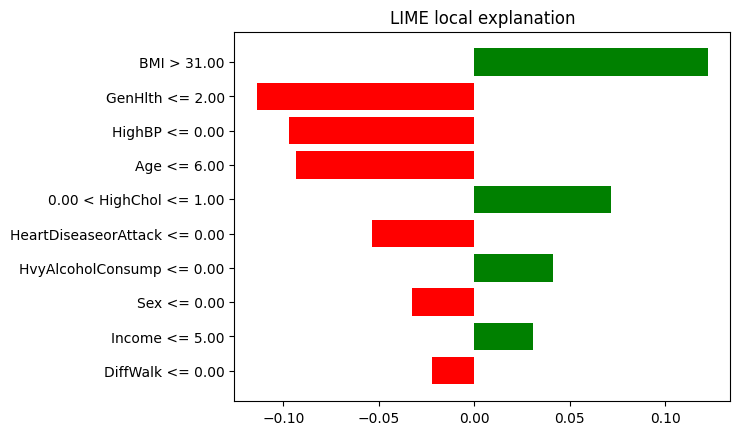

In [30]:
# Visualise LIME explanation as a plot
fig = lime_exp.as_pyplot_figure()
plt.title("LIME local explanation")
plt.show()